### 1. Diferenças em diferenças

O conjunto de códigos abaixo replica o Capítulo 7, intitulado **"Diferenças em diferenças"**, do livro *Avaliação de Impacto na Prática*, segunda edição, dos autores Paul J. Gertler, Sebastián Martínez, Patrick Premand, Laura B. Rawlings e Christel M. J. Vermeersch. Este capítulo aborda a avaliação de impacto de políticas públicas por meio do método de difeenças em diferenças. O método diferença em diferenças compara as mudanças nos resultados ao longo do tempo entre uma população que está inscrita em um programa (o grupo de tratamento) e uma população que não está (o grupo de comparação).  O livro, em formato digital, pode ser acessado gratuitamente no seguinte site: [Avaliação de Impacto na Prática](https://publications.iadb.org/pt/avaliacao-de-impacto-na-pratica-segunda-edicao).

### 2. Bibliotecas

In [3]:
# Manipulando os dados
import pandas as pd

# estatística
import statsmodels.formula.api as smf

# Visualização
import matplotlib.pyplot as plt

# Configurações
import warnings
import os

### 3. Configurações

In [ ]:
# Definindo o diretorio
os.chdir("diretorio")

# Exibir todas as linhas e colunas
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Não exibir avisos
warnings.filterwarnings("ignore")

### 4. manipulando os dados

In [5]:
# Importando os dados
dados = pd.read_stata("evaluation.dta")

# Primeiras observações
dados.head()

,locality_identifier,household_identifier,treatment_locality,promotion_locality,eligible,enrolled,enrolled_rp,poverty_index,round,health_expenditures,age_hh,age_sp,educ_hh,educ_sp,female_hh,indigenous,hhsize,dirtfloor,bathroom,land,hospital_distance,hospital
0,26.0,5.0,1.0,1.0,1.0,1.0,1.0,55.950542,0.0,15.185455,24.0,23.0,0.0,6.0,0.0,0.0,4.0,1,0,1,124.819966,0.0
1,26.0,5.0,1.0,1.0,1.0,1.0,1.0,55.950542,1.0,19.580902,25.0,24.0,0.0,6.0,0.0,0.0,4.0,1,0,1,124.819966,0.0
2,26.0,11.0,1.0,1.0,1.0,1.0,0.0,46.058731,0.0,13.076257,30.0,26.0,4.0,0.0,0.0,0.0,6.0,1,0,2,124.819966,0.0
3,26.0,11.0,1.0,1.0,1.0,1.0,0.0,46.058731,1.0,2.398854,31.0,27.0,4.0,0.0,0.0,0.0,6.0,1,0,2,124.819966,1.0
4,26.0,13.0,1.0,1.0,1.0,1.0,0.0,54.095825,1.0,0.000000,59.0,57.0,0.0,0.0,0.0,0.0,6.0,1,0,4,124.819966,1.0


In [6]:
# Formato dos dados
dados.shape

(19827, 22)

In [7]:
# Informaçoes sobre o df
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19827 entries, 0 to 19826
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   locality_identifier   19827 non-null  float32
 1   household_identifier  19827 non-null  float32
 2   treatment_locality    19827 non-null  float32
 3   promotion_locality    19827 non-null  float32
 4   eligible              19827 non-null  float32
 5   enrolled              19827 non-null  float32
 6   enrolled_rp           19827 non-null  float32
 7   poverty_index         19827 non-null  float32
 8   round                 19827 non-null  float32
 9   health_expenditures   19827 non-null  float32
 10  age_hh                19827 non-null  float32
 11  age_sp                19827 non-null  float32
 12  educ_hh               19827 non-null  float32
 13  educ_sp               19827 non-null  float32
 14  female_hh             19827 non-null  float32
 15  indigenous         

In [8]:
# Verificando se há dados faltantes. 
dados.isna().sum().sort_values(ascending=False)

hospital                8570
household_identifier       0
hospital_distance          0
land                       0
bathroom                   0
dirtfloor                  0
hhsize                     0
indigenous                 0
female_hh                  0
educ_sp                    0
educ_hh                    0
locality_identifier        0
age_hh                     0
health_expenditures        0
round                      0
poverty_index              0
enrolled_rp                0
enrolled                   0
eligible                   0
promotion_locality         0
treatment_locality         0
age_sp                     0
dtype: int64

In [9]:
# Removendo a coluna hospital
dados.drop('hospital', axis=1, inplace=True)

In [10]:
# Estatísticas das variáveis
dados.describe().T

,count,mean,std,min,25%,50%,75%,max
locality_identifier,19827.0,73.933472,55.076599,1.000000,30.000000,59.000000,112.000000,200.000000
household_identifier,19827.0,8038.973145,4569.468262,2.000000,3989.500000,8040.000000,12033.000000,15778.000000
treatment_locality,19827.0,0.500277,0.500017,0.000000,0.000000,1.000000,1.000000,1.000000
promotion_locality,19827.0,0.512685,0.499851,0.000000,0.000000,1.000000,1.000000,1.000000
eligible,19827.0,0.567761,0.495377,0.000000,0.000000,1.000000,1.000000,1.000000
enrolled,19827.0,0.299037,0.457822,0.000000,0.000000,0.000000,1.000000,1.000000
enrolled_rp,19827.0,0.293287,0.455238,0.000000,0.000000,0.000000,1.000000,1.000000
poverty_index,19827.0,56.789566,10.686106,20.479134,49.652241,56.414219,62.905720,100.000000
round,19827.0,0.500025,0.500013,0.000000,0.000000,1.000000,1.000000,1.000000
health_expenditures,19827.0,17.035091,9.291589,0.000000,11.621977,16.051678,21.236842,116.830643


### 5. Avaliar o impacto do HISP: Uso do método de diferenças em diferenças

O método diferença em diferenças pode ser usado para avaliar o nosso Programa de Subsídio ao Seguro Saúde (HISP). Neste cenário, você tem dados de dois períodos distintos para dois grupos de famílias: um grupo que se inscreveu no programa e outro grupo que não. 

In [11]:
# Manter apenas apenas as observações onde treatment_locality é 1
dados = dados[dados['treatment_locality'] ==  1]

#### Quadro 7.2 Avaliar o HISP: comparação médias da diferença em diferenças

In [12]:
# Média controle antes da intervenção
media_00 = dados.loc[(dados['round']==0) & (dados['enrolled']==0), 'health_expenditures'].mean()

# Média controle após a intervenção
media_10 = dados.loc[(dados['round']==1)&(dados['enrolled']==0), 'health_expenditures'].mean()

# Média tratamento antes da intervenção
media_01 = dados.loc[(dados['round']==0)&(dados['enrolled']==1), 'health_expenditures'].mean()

# Média tratamento após a intervenção
media_11 = dados.loc[(dados['round']==1)&(dados['enrolled']==1), 'health_expenditures'].mean()

In [13]:
delta_did = (media_11 - media_01) - (media_10 - media_00)
print(f"O efeito do programa (DiD) é de {delta_did:.2f}, indicando uma redução média de {abs(delta_did):.2f} nos gastos hospitalares entre os participantes.")

O efeito do programa (DiD) é de -8.16, indicando uma redução média de 8.16 nos gastos hospitalares entre os participantes.


##### Visualizando os efeitos

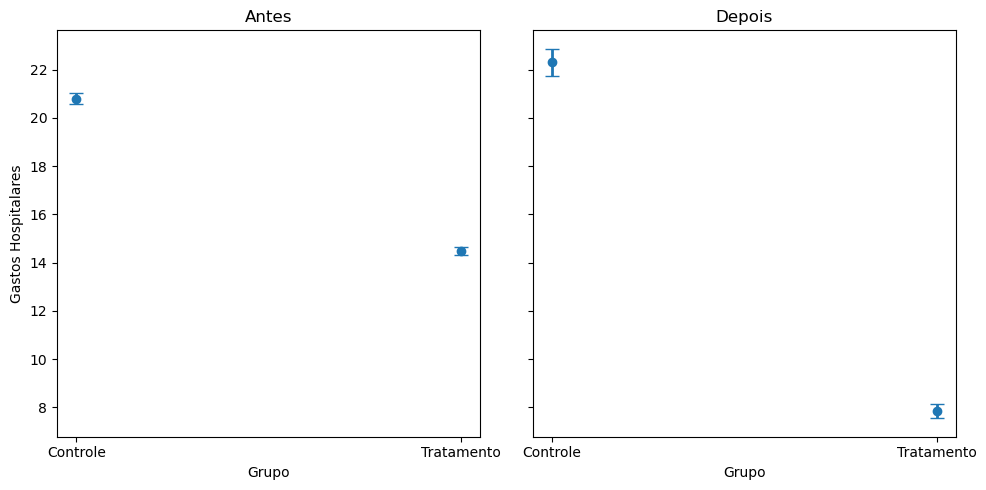

In [65]:
# Calcular média e IC 95% manualmente
summary = dados.groupby(['round', 'enrolled'])['health_expenditures'].agg(['mean', 'count', 'std'])
summary['se'] = summary['std'] / np.sqrt(summary['count'])
summary['ci_lower'] = summary['mean'] - 1.96 * summary['se']
summary['ci_upper'] = summary['mean'] + 1.96 * summary['se']

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for idx, (round_val, group) in enumerate(summary.groupby(level=0)):
    ax = axes[idx]
    group.reset_index(inplace=True)

    # Cores e labels
    labels = ['Controle', 'Tratamento']
    x = [0, 1]

    ax.errorbar(x, group['mean'], 
                yerr=[group['mean'] - group['ci_lower'], group['ci_upper'] - group['mean']],
                fmt='o', capsize=5, linewidth=2)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title('Antes' if round_val == 0 else 'Depois')
    ax.set_xlabel('Grupo')

axes[0].set_ylabel('Gastos Hospitalares')
plt.tight_layout()
plt.show()


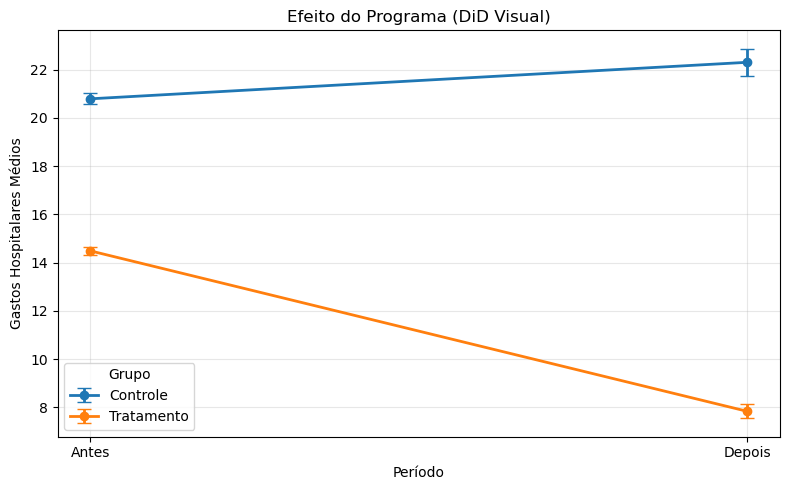

In [66]:
# Calcular média e IC 95%
summary = dados.groupby(['round', 'enrolled'])['health_expenditures'].agg(['mean', 'count', 'std'])
summary['se'] = summary['std'] / np.sqrt(summary['count'])
summary['lower'] = summary['mean'] - 1.96 * summary['se']
summary['upper'] = summary['mean'] + 1.96 * summary['se']
summary = summary.reset_index()

# Mapear labels
labels_round = {0: "Antes", 1: "Depois"}
labels_group = {0: "Controle", 1: "Tratamento"}

summary['round_label'] = summary['round'].map(labels_round)
summary['group_label'] = summary['enrolled'].map(labels_group)

# Plot
plt.figure(figsize=(8,5))

for group, data in summary.groupby('group_label'):
    plt.errorbar(data['round_label'], data['mean'], 
                 yerr=[data['mean'] - data['lower'], data['upper'] - data['mean']],
                 fmt='o-', capsize=5, linewidth=2, label=group)

plt.xlabel("Período")
plt.ylabel("Gastos Hospitalares Médios")
plt.title("Efeito do Programa (DiD Visual)")
plt.legend(title="Grupo")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### Qadro 7.3 Avaliar o HISP: diferença em diferenças com análise de regressão

Ao utilizar regressão linear simples o efeito do programa é dado por `round:enrolled` -8.1629 

In [67]:
# Filtrar os dados como no R
df_filtered = dados[dados['treatment_locality'] == 1]

# Regressão com interação e erros robustos por cluster
model = smf.ols("health_expenditures ~ round * enrolled", data=df_filtered).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_filtered['locality_identifier']}
)

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     health_expenditures   R-squared:                       0.344
Model:                             OLS   Adj. R-squared:                  0.343
Method:                  Least Squares   F-statistic:                     814.0
Date:                 Wed, 15 Oct 2025   Prob (F-statistic):           1.35e-69
Time:                         19:24:34   Log-Likelihood:                -34590.
No. Observations:                 9919   AIC:                         6.919e+04
Df Residuals:                     9915   BIC:                         6.922e+04
Df Model:                            3                                         
Covariance Type:               cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         20.7915      0.1

Ao utilizar mais covariáveis de controle ainda obtemos que o programa diminui os gastos com despesas hospitalares em USS 8,16 como é dado por `round:enrolled `

In [68]:
# Filtrar dados como no R
df_filtered = dados[dados['treatment_locality'] == 1]

# Definir a fórmula com interação e covariáveis adicionais
formula = (
    "health_expenditures ~ round * enrolled + "
    "age_hh + age_sp + educ_hh + educ_sp + "
    "female_hh + indigenous + hhsize + dirtfloor + "
    "bathroom + land + hospital_distance"
)

# Regressão com cluster robust standard errors
model_cov = smf.ols(formula, data=df_filtered).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_filtered['locality_identifier']}
)

# Sumário
print(model_cov.summary())


                             OLS Regression Results                            
Dep. Variable:     health_expenditures   R-squared:                       0.552
Model:                             OLS   Adj. R-squared:                  0.551
Method:                  Least Squares   F-statistic:                     2410.
Date:                 Wed, 15 Oct 2025   Prob (F-statistic):          1.13e-118
Time:                         19:28:20   Log-Likelihood:                -32700.
No. Observations:                 9919   AIC:                         6.543e+04
Df Residuals:                     9904   BIC:                         6.554e+04
Df Model:                           14                                         
Covariance Type:               cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            27.3946